In [1]:
import glob
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import tqdm

In [2]:
eval_output_format = "../eval_out/domain{domain}/step{step}.zarr"

In [4]:
dss = []
for step in tqdm.trange(50):
    step_ds = xr.concat([xr.open_zarr(eval_output_format.format(domain=domain, step=step)) for domain in range(3)], dim="grid_index")
    if step == 0:
        start_time = step_ds.start_time.values
    else:
        # step_ds = step_ds.isel(start_time=0)
        # assert all(start_time == step_ds.start_time.values), f"Start time mismatch: {start_time} vs {step_ds.start_time.values}"
        step_ds = step_ds.assign_coords(
            elapsed_forecast_duration=step_ds.elapsed_forecast_duration.values + step_ds.start_time.values - start_time,
            start_time=start_time
        )

    dss.append(step_ds)
ds = xr.concat(dss, dim="elapsed_forecast_duration")

100%|██████████| 50/50 [00:03<00:00, 16.04it/s]


In [5]:
ds

<xarray.Dataset> Size: 327MB
Dimensions:                    (start_time: 1, elapsed_forecast_duration: 50,
                                grid_index: 1572864, state_feature: 1)
Coordinates:
  * start_time                 (start_time) datetime64[ns] 8B 2020-02-12T00:3...
  * elapsed_forecast_duration  (elapsed_forecast_duration) timedelta64[ns] 400B ...
  * grid_index                 (grid_index) int64 13MB 5618205 ... 3934314
  * state_feature              (state_feature) <U13 52B 't_2m'
    time                       (elapsed_forecast_duration) datetime64[ns] 400B ...
Data variables:
    state                      (start_time, elapsed_forecast_duration, grid_index, state_feature) float32 315MB dask.array<chunksize=(1, 1, 524288, 1), meta=np.ndarray>

In [6]:
grid = xr.open_zarr("../data/grid.zarr")

In [7]:
grid

<xarray.Dataset> Size: 566MB
Dimensions:  (cell: 11792076)
Coordinates:
  * cell     (cell) int64 94MB 0 1 2 3 4 ... 11792072 11792073 11792074 11792075
    clat     (cell) float64 94MB dask.array<chunksize=(2948019,), meta=np.ndarray>
    clon     (cell) float64 94MB dask.array<chunksize=(2948019,), meta=np.ndarray>
    x        (cell) float64 94MB dask.array<chunksize=(2948019,), meta=np.ndarray>
    y        (cell) float64 94MB dask.array<chunksize=(2948019,), meta=np.ndarray>
    z        (cell) float64 94MB dask.array<chunksize=(2948019,), meta=np.ndarray>
Data variables:
    *empty*

In [8]:
grid_sel = grid.sel(cell=ds.grid_index.values)
ds["clat"] = xr.DataArray(np.rad2deg(grid_sel.clat.values), dims="grid_index")
ds["clon"] = xr.DataArray(np.rad2deg(grid_sel.clon.values), dims="grid_index")
ds = ds.set_coords(["clat", "clon"])

In [9]:
ds

<xarray.Dataset> Size: 352MB
Dimensions:                    (start_time: 1, elapsed_forecast_duration: 50,
                                grid_index: 1572864, state_feature: 1)
Coordinates:
  * start_time                 (start_time) datetime64[ns] 8B 2020-02-12T00:3...
  * elapsed_forecast_duration  (elapsed_forecast_duration) timedelta64[ns] 400B ...
  * grid_index                 (grid_index) int64 13MB 5618205 ... 3934314
  * state_feature              (state_feature) <U13 52B 't_2m'
    time                       (elapsed_forecast_duration) datetime64[ns] 400B ...
    clat                       (grid_index) float64 13MB 13.23 13.23 ... 13.7
    clon                       (grid_index) float64 13MB -58.39 ... -54.17
Data variables:
    state                      (start_time, elapsed_forecast_duration, grid_index, state_feature) float32 315MB dask.array<chunksize=(1, 1, 524288, 1), meta=np.ndarray>

In [20]:
output = ds.isel(start_time=0, elapsed_forecast_duration=15, state_feature=0)

In [21]:
np.sum(np.isnan(output.state.values))

0

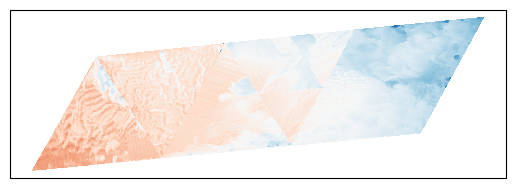

In [22]:
fig, axes = plt.subplots(1,1,
    subplot_kw={"projection": ccrs.PlateCarree()},
)

axes = np.array([axes])


# Plot ground truth in first column
ax = axes[0]
lons = output.clon
lats = output.clat

ax.tripcolor(
    lons,
    lats,
    output.state.values,
    cmap="RdBu_r",
)
plt.show()
plt.close()